# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Armon Haji

**Date:** 9/6/2026

In [8]:
# Your Phase 1 solution to the problem goes here.


In [9]:
import pandas as pd

airbnb = pd.read_csv("./data/airbnb_hw.csv")
airbnb.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


In [10]:
airbnb["Price"].head(20)

0     145
1      37
2      28
3     199
4     549
5     149
6     250
7      90
8     270
9     290
10    170
11     59
12     49
13     68
14    285
15     75
16    145
17    100
18    150
19    700
Name: Price, dtype: str

In [11]:
airbnb["Price"] = airbnb["Price"].str.replace(",", "")
airbnb["Price"] = pd.to_numeric(airbnb["Price"])
airbnb["Price"].isna().sum()

0

In [12]:
## Some of the prices included commas. I removed the commas to turn them into pure numeric form and I got 0 missing values.

In [13]:
police = pd.read_csv("./data/mn_police_use_of_force.csv")
police["subject_injury"].value_counts(dropna=False)

subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64

In [14]:
police["subject_injury"].isna().mean()

0.7619342359767892

In [15]:
pd.crosstab(
    police["force_type"],
    police["subject_injury"].fillna("Missing")
)

subject_injury,Missing,No,Yes
force_type,,,
Baton,2,0,2
Bodily Force,7051,1093,1286
Chemical Irritant,1421,131,41
Firearm,0,2,0
Gun Point Display,27,33,44
Improvised Weapon,74,34,40
Less Lethal,87,0,0
Less Lethal Projectile,0,1,2
Maximal Restraint Technique,170,0,0


In [16]:
## We can see that about 76% of the subject injury values are missing which is definitely a big concern for us. 
# It differs among data type. Firearm has none missing, but Less Lethal and Maximal
# Restraint Technique are all missing.

In [17]:
## Now moving to Q2

In [18]:
sharks = pd.read_excel("./data/GSAF5.xls")
sharks.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
sharks = sharks.dropna(axis=1, how="all")
sharks.shape

(7117, 23)

In [20]:
sharks["Year"] = pd.to_numeric(sharks["Year"])
sharks["Year"].min(), sharks["Year"].max()

(0.0, 2026.0)

In [21]:
# The year value ranges from 0 to 2026. This is an issue because 0 seems not likely.

In [22]:
sharks_1940 = sharks[sharks["Year"] > 1940]

<Axes: xlabel='Year'>

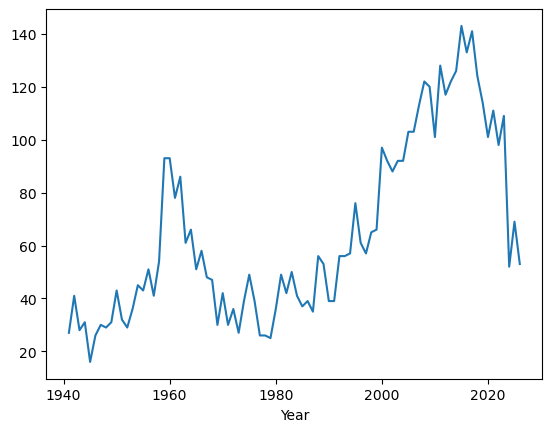

In [23]:
sharks_1940["Year"].value_counts().sort_index().plot()

In [24]:
## It appears that there were spikes around 1950-1960 and 2000-2010. There were a lot of ups and downs
## but it generally increased over time.

In [25]:
sharks_1940["Age"].value_counts(dropna=False).head(20)

Age
NaN    1763
16       80
19       80
17       77
15       76
20       73
18       73
17       71
20       67
15       65
25       65
21       64
22       63
18       62
24       58
19       57
14       57
16       56
21       56
14       52
Name: count, dtype: int64

<Axes: >

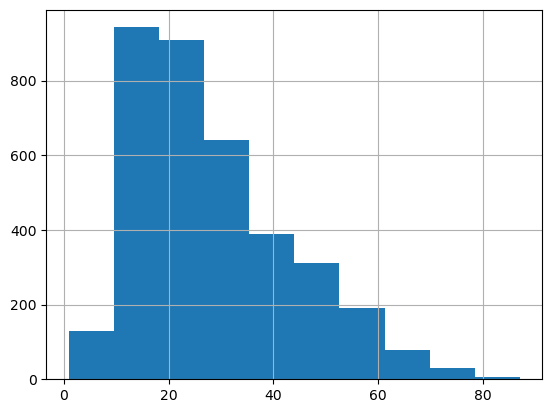

In [26]:
age_clean = sharks_1940["Age"].astype(str)
age_clean = age_clean[age_clean.str.isdigit()].astype(int)
age_clean.hist()

In [27]:
sharks_1940["Sex"].value_counts(dropna=False)

Sex
M        4367
F         727
NaN       447
M           7
?           2
F           2
M F         1
 M          1
m           1
lli         1
M x 2       1
Name: count, dtype: int64

In [28]:
known_sex = sharks_1940[sharks_1940["Sex"].isin(["M", "F"])]
(known_sex["Sex"] == "M").mean()

0.8572830781311347

In [29]:
## The proportion of victims which are male is 85.7% 

In [30]:
sharks_1940["Type"].value_counts(dropna=False)

Type
Unprovoked             4143
Provoked                525
Invalid                 399
Watercraft              278
Sea Disaster            156
Questionable             27
NaN                      14
Boat                      7
 Provoked                 2
UNprovoked                1
unprovoked                1
?                         1
Unconfirmed               1
Unverified                1
Under investigation       1
Name: count, dtype: int64

In [31]:
sharks_1940["Type_clean"] = "Unknown"

sharks_1940.loc[sharks_1940["Type"] == "Provoked", "Type_clean"] = "Provoked"
sharks_1940.loc[sharks_1940["Type"] == "Unprovoked", "Type_clean"] = "Unprovoked"

sharks_1940["Type_clean"].value_counts()

Type_clean
Unprovoked    4143
Unknown        889
Provoked       525
Name: count, dtype: int64

In [32]:
4143/5557

0.7455461579989203

In [33]:
# Around 74.5% of attacks are unprovoked.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 751339e378d98e613495595b998ebbe13df5e4ef
- **AI tool and model used:** ChatGPT

### *Prompts used

1. Please review my work for this DS 3001 assignment. Please find some meaningful ways to either fix or improve the parts. The parts include the Airbnb price cleaning, police subject_injury cleaning and missingness analysis, and shark attack Year, Age, Sex, and Type cleaning. Make sure you focus on correctness. Give me a concise numbered list of proposed changes.
2. Provide code implementing those improvements. Keep the code understandable for me to learn as a student and explain any new content.

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Make the Airbnb price conversion more robust by using numeric coercion and checking whether any values become missing after cleaning.

2. Create an explicitly cleaned subject_injury variable and examine missingness by force type using proportions instead of only raw counts.

3. Improve Year cleaning by coercing invalid values to missing, correcting the 1940 boundary condition, and checking for unrealistic years before analyzing the trend.

4. Improve Age cleaning by extracting usable numeric ages from messy text values instead of keeping only strings made entirely of digits, then remove clearly unrealistic ages.

5. Standardize Sex values by stripping spaces and converting text to uppercase before calculating the male proportion from known M/F observations.

6. Standardize Type values for capitalization and spacing before classifying records as Provoked, Unprovoked, or Unknown, then calculate the unprovoked proportion directly in Python.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Used errors="coerce" to make the conversion safer. Verified that the cleaned Price column still had 0 missing values.|
| 2 | Accept | Created a cleaned injury variable and used normalized cross-tabs to compare missingness across force types instead of only raw counts.|
| 3 | Accept | Used numeric coercion and changed the filter from > 1940 to >= 1940. Verified that the filtered range was 1940–2026.|
| 4 | Accept | Extracted numeric ages from messy text instead of only keeping pure digits. Phase 1 retained 3,629 ages while Phase 2 retained 3,739, recovering 110 additional values.|
| 5 | Accept | Removed extra spaces and standardized capitalization before calculating the male proportion. The result remained about 85%, showing the cleaning did not materially distort the result.|
| 6 | Accept | Standardized capitalization and spacing before categorizing attacks. Unprovoked increased from 4,143 to 4,163 and Provoked from 525 to 528, showing that valid records were recovered.|

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [43]:
# Your Phase 2 solution to the problem goes here.

In [44]:
# Airbnb
airbnb2 = pd.read_csv("./data/airbnb_hw.csv")

airbnb2["Price"] = airbnb2["Price"].str.replace(",", "")
airbnb2["Price"] = pd.to_numeric(airbnb2["Price"], errors="coerce")

airbnb2["Price"].isna().sum()

0

In [45]:
# Police data
police2 = pd.read_csv("./data/mn_police_use_of_force.csv")

police2["subject_injury_clean"] = police2["subject_injury"].fillna("Missing")

pd.crosstab(
    police2["force_type"],
    police2["subject_injury_clean"],
    normalize="index"
)

subject_injury_clean,Missing,No,Yes
force_type,,,
Baton,0.500000,0.000000,0.500000
Bodily Force,0.747720,0.115907,0.136373
Chemical Irritant,0.892028,0.082235,0.025738
Firearm,0.000000,1.000000,0.000000
Gun Point Display,0.259615,0.317308,0.423077
Improvised Weapon,0.500000,0.229730,0.270270
Less Lethal,1.000000,0.000000,0.000000
Less Lethal Projectile,0.000000,0.333333,0.666667
Maximal Restraint Technique,1.000000,0.000000,0.000000


<Axes: xlabel='Year'>

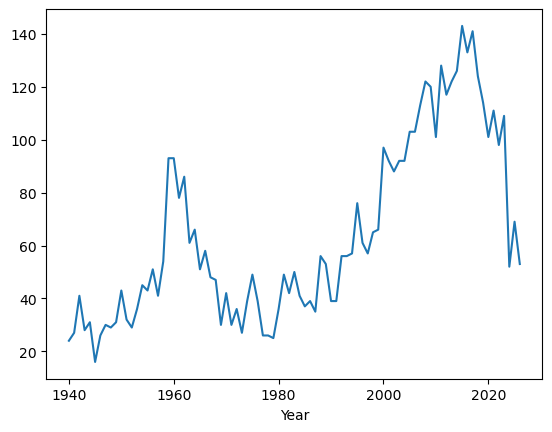

In [46]:
# Shark data
sharks2 = pd.read_excel("./data/GSAF5.xls")
sharks2 = sharks2.dropna(axis=1, how="all")

sharks2["Year"] = pd.to_numeric(sharks2["Year"], errors="coerce")
sharks2 = sharks2[sharks2["Year"] >= 1940]

sharks2["Year"].value_counts().sort_index().plot()

In [47]:
sharks2["Year"].min(), sharks2["Year"].max()

(1940.0, 2026.0)

<Axes: >

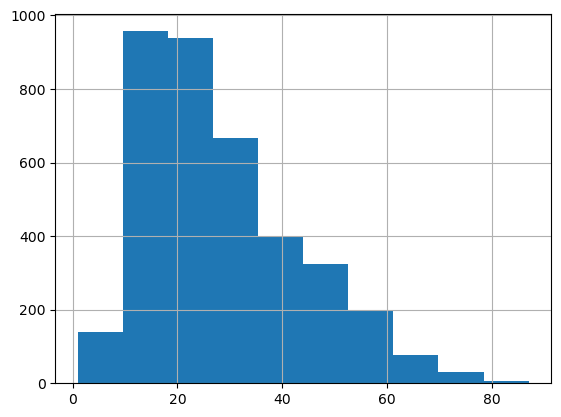

In [48]:
sharks2["Age_clean"] = (
    sharks2["Age"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

sharks2 = sharks2[
    (sharks2["Age_clean"].isna()) |
    (sharks2["Age_clean"] <= 100)
]

sharks2["Age_clean"].dropna().hist()

In [49]:
sharks2["Age_clean"].notna().sum()

3739

In [50]:
sharks2["Sex_clean"] = sharks2["Sex"].astype(str).str.strip().str.upper()

known_sex2 = sharks2[sharks2["Sex_clean"].isin(["M", "F"])]

(known_sex2["Sex_clean"] == "M").mean()

0.8571707317073171

In [51]:
# About 85.7% of victims with a known sex were male.

In [52]:
sharks2["Type_clean"] = sharks2["Type"].astype(str).str.strip().str.lower()

sharks2["Type_clean"] = sharks2["Type_clean"].replace({
    "provoked": "Provoked",
    "unprovoked": "Unprovoked"
})

sharks2.loc[
    ~sharks2["Type_clean"].isin(["Provoked", "Unprovoked"]),
    "Type_clean"
] = "Unknown"

sharks2["Type_clean"].value_counts()

Type_clean
Unprovoked    4163
Unknown        890
Provoked       528
Name: count, dtype: int64

In [53]:
(sharks2["Type_clean"] == "Unprovoked").mean()

0.7459236695932628

In [54]:
# About 74.6% of attacks were unprovoked.

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

ChatGPT definitely helped my project become more exhaustive, accurate, and robust. Some clear fixes were changing >1940 to >=1940 for accuracy purposes. Also adding in "errors='coerce'" helped to change invalid numbers from error to missing. The Age cleaning improved by recovering numeric ages from messy text values instead of only keeping values that were already pure numbers, which increased the number of usable ages. The final solution was verified checking the cleaned year range, comparing the number of usable age values before and after the revision, and confirming that the Airbnb price cleaning still resulted in zero missing values. I will say that there are still some concerns because certain age values are ambiguous. Some of the attack types are still classified as unknown and the police injury variable contains a large amount of missing data. The 2026 shark attack counts may also be incomplete because the year is not finished yet.